In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt .
import seaborn as sns


print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (301, 9)


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

In [ ]:
df.to_csv("../data/car_data_cleaned.csv", index=False)

Phase - 2

In [ ]:
plt.style.use('ggplot')


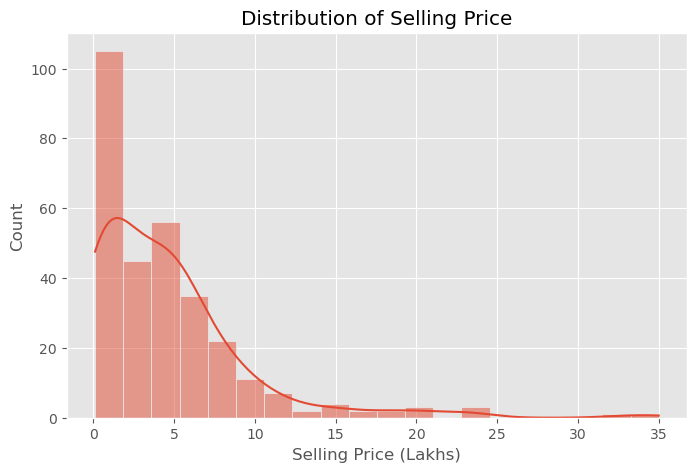

In [ ]:
plt.figure(figsize=(8,5)) # height width
sns.histplot(df['Selling_Price'], bins=20, kde=True)  # interval

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Count")

plt.show()

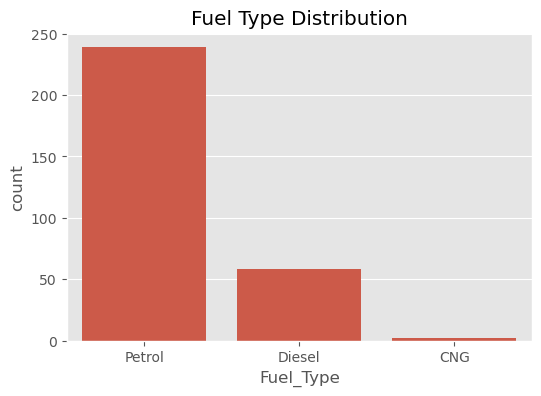

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='Fuel_Type', data=df)

plt.title("Fuel Type Distribution")

plt.show()

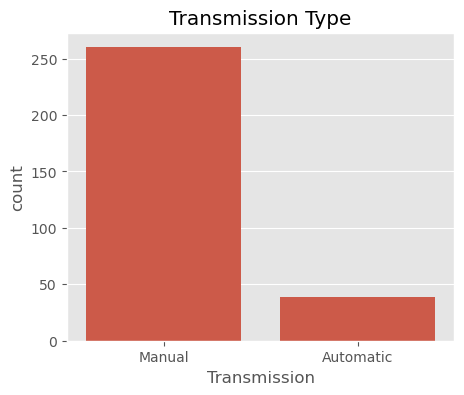

In [11]:
plt.figure(figsize=(5,4))

sns.countplot(x='Transmission', data=df)

plt.title("Transmission Type")

plt.show()

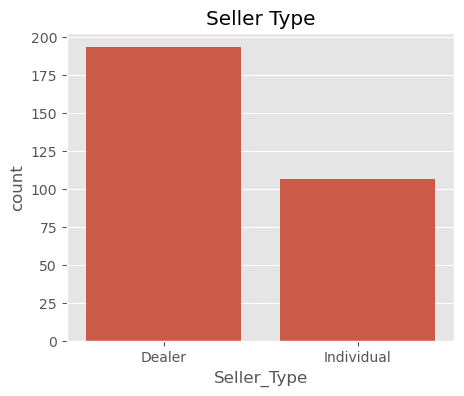

In [12]:
plt.figure(figsize=(5,4))

sns.countplot(x='Seller_Type', data=df)

plt.title("Seller Type")

plt.show()

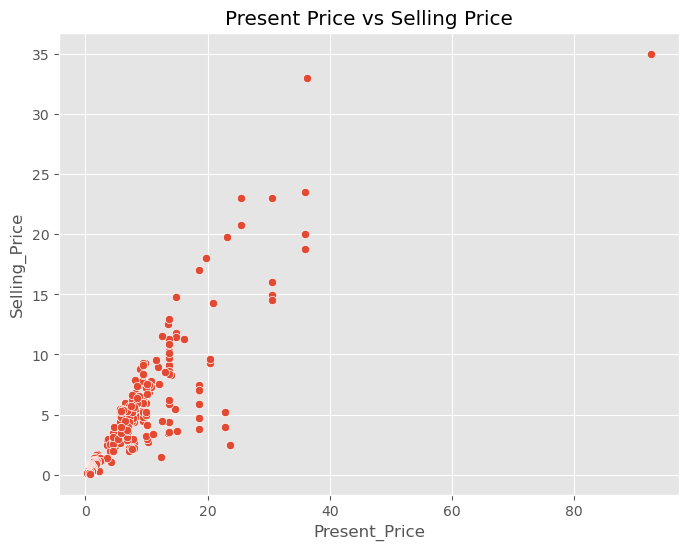

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title("Present Price vs Selling Price")

plt.show()

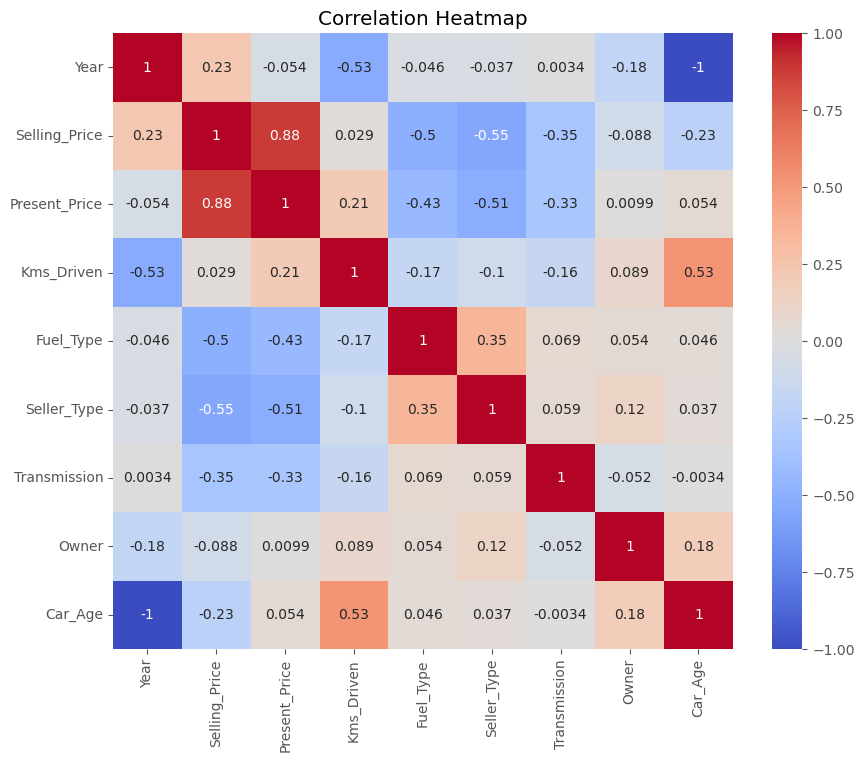

In [ ]:
df_heatmap = df.copy()

df_heatmap = df_heatmap.drop('Car_Name', axis=1)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    df_heatmap[col] = le.fit_transform(df_heatmap[col])

plt.figure(figsize=(10,8))

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


# Phase 3: Data Preprocessing & Feature Engineering


In [17]:
df_ml = df.copy()

df_ml.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [18]:
df_ml.drop(['Car_Name','Year'], axis=1, inplace=True)

df_ml.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [ ]:
print(df_ml.columns)

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


In [20]:
df_ml = pd.get_dummies(
    df_ml,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission'],
    drop_first=True
)

df_ml.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


In [21]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Selling_Price           299 non-null    float64
 1   Present_Price           299 non-null    float64
 2   Kms_Driven              299 non-null    int64  
 3   Owner                   299 non-null    int64  
 4   Car_Age                 299 non-null    int64  
 5   Fuel_Type_Diesel        299 non-null    bool   
 6   Fuel_Type_Petrol        299 non-null    bool   
 7   Seller_Type_Individual  299 non-null    bool   
 8   Transmission_Manual     299 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 15.2 KB


In [ ]:
X = df_ml.drop("Selling_Price", axis=1)

y = df_ml["Selling_Price"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (299, 8)
Target Shape : (299,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Data : (239, 8)
Testing Data : (60, 8)
Training Target : (239,)
Testing Target : (60,)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
print(X_train_scaled[:5])

[[ 0.0792308  -0.55609426 -0.17370208 -0.46310243 -0.48162097  0.48820279
  -0.73616267  0.386055  ]
 [-0.77591555 -1.1560003  -0.17370208  1.97328237 -0.48162097  0.48820279
   1.35839541 -2.5903045 ]
 [-0.78385457 -0.08727564 -0.17370208  0.23300751 -0.48162097  0.48820279
   1.35839541  0.386055  ]
 [-0.73508628  0.37429979 -0.17370208  1.27717243 -0.48162097  0.48820279
   1.35839541  0.386055  ]
 [-0.28709847  0.70095318 -0.17370208  0.92911746 -0.48162097  0.48820279
  -0.73616267  0.386055  ]]
